## Stability of plasma in Nuclear fusion

In tokamak reactors (such as ITER), maintaining a stable plasma is one of the key challenges to achieving controlled fusion. Disruptions can lead to energy loss and damage to the reactor. In this project, I’ll use real experimental data and train a machine learning model—specifically, XGBoost—to predict whether the plasma is stable or at risk of a disruption, based on physical parameters like density, magnetic field, and temperature. The goal of this project is to explore how AI can help prevent critical instabilities.

***Table of Contents :***

1.  Importing Data
2.  Handling Missing and Invalid Data
3.  Removing Columns Incompatible with XGBoost
4.  Preparing Data for Training
5.  Model Training - XGBoost Classifier
6.  Cross-Validation to Evaluate Model Robustness
7.  Learning Curve Analysis
8.  Learning Curve  Interpretation
9.  Verifying Data Leakage and Feature Influence
10. Hyperparameter Optimization with GridSearchCV
11. Model Interpretation with SHAP
12. Feature Reduction – Selecting Top SHAP Features
13. Train a Simpler Model on the Top 20 Features
14. Cross-Validation on Reduced Model
15. Model Explainability with SHAP (Reduced Model)


In [2]:
# Importing relevants librairies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
from xgboost import XGBClassifier



pd.set_option('display.max_columns', None)



In [3]:
df = pd.read_excel("/Users/loebelisabeth/Downloads/PlasmaStability/HDB5V2.3.xlsx")
df.shape
df.head()



,TOK,TOK_ID,DIVNAME,LCUPDATE,DATE,SHOT,TIME,TIME_ID,T1,T2,AUXHEAT,PHASE,HYBRID,ITB,ITBTYPE,ELMTYPE,ELMFREQ,ELMMAX,ELMDUR,ELMINT,OLTIME,LHTIME,TPI,ISEQ,MEFF,PGASA,PGASZ,BGASA,BGASZ,BGASA2,BGASZ2,PELLET,FUELRATE,XGASZ,XGASA,CONFIG,RGEO,RMAG,AMIN,KAPPA,KAPPAA,KAREA,DELTA,DELTAU,DELTAL,INDENT,AREA,VOL,SURFFORM,SEPLIM,XPLIM,WALMAT,DIVMAT,LIMMAT,EVAP,DALFMP,DALFDV,IGRADB,BT,IEML,PREMAG,IP,VSURF,Q95,SH95,BEILI2,BEIMHD,BEPMHD,BETMHD,BEPDIA,BMHDMDIA,TAUCR,FBS,RHOQ2,RHOINV,NEL,NELFORM,DNELDT,NEV,NE0,NE0TSC,ZEFF,ZEFFNEO,PRAD,POHM,ENBI,PINJ,BSOURCE,PINJ2,BSOURCE2,COCTR,PNBI,PFLOSS,ECHFREQ,ECHMODE,ECHLOC,PECRHC,PECRH,ICFREQ,ICSCHEME,ICANTEN,PICRHC,PICRH,PALPHA,DWDIA,DWDIAPAR,DWMHD,DWHC,TEV,TE0,TE0TSC,TIV,TI0,TICX0,WDIA,WMHD,WKIN,WEKIN,WIKIN,WROT,WFPER,WFPAR,WFFORM,WFANI,WFICRH,WFICRHP,WFICFORM,ICFORM,WFANIIC,TAUDIA,TAUMHD,TAUTH1,TAUTH2,WTOT,WTH,PL,PLTH,TAUTOT],TAUTH,TAUC92,TAUC93,H89,HITER96L,H93,HITER92Y,HEPS97,HIPB98Y,HIPB98Y1,HIPB98Y2,HIPB98Y3,HIPB98Y4,OMGAIMP0,OMGAIMPH,OMGAM0,OMGAMH,SPIN,TORQ,TORQBM,TORQIN,VTOR0,VTORV,VTORIMP,STANDARD,SELDB1,SELDB2,SELDB2X,IAEA92,DB2P5,DB2P8,DB3IS,DB3V5,IAE2000N,IAE2000X,HMWS2003,IAE2004S,IAE2004I,DB3DONLY,HMWS2005,OJK2006,SELDB3,SELDB3X,SELDB4,AAREA,STDDB4V5,NESEP,NESOL,PMAIN,PDIV,GP_MAIN,GP_DIV,SELDB5,STD3
0,ASDEX,1,DV-IPRE,19940125,19820622,5980,0.960,960,0.958,0.962,NONE,OHM,UNKNOWN,UNKNOWN,NaN,NONE,NaN,0.0,0.0,0.0,1.11,1.166,1.0,NONE,2.0,2.0,1,0,0,0,0,NONE,,0,0.0,DN,1.668,1.706,0.3840,1.0420,1.041991,1.042,0.0,0.0,0.0,0.0,0.4827,5.058,25.822875,0.2083,NaN,SS,TI2,NONE,NONE,NaN,NaN,NaN,2.204,0.0,NaN,293900.0,1.07300,3.740,NaN,1.049,0.4181,0.4181,0.001895,0.4116,0.10200,1.146752,NaN,NaN,0.289279,29160000000000000000,0.0,5493000000000000000,21510000000000000000,43000000000000000000,,NaN,NaN,0.0,315400.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NONE,NONE,0.0,0.0,0.0,NONE,NONE,0.0,0.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,27950.0,28390.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.08862,0.09003,NaN,0.08862,27950.0,27950.0,315400.0,315400.0,0.08862,0.08862,1.0000,1.0000,1.417,1.042,0.6718,0.8681,0.9374,1.030,1.010,0.9241,0.9224,0.8177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1.111111e+09,1.111110e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.111111e+09,1100.0,0.0,NaN,NaN,,,NaN,NaN,NaN,NaN,0,0.0
1,ASDEX,1,DV-IPRE,19940125,19820622,5980,1.010,1010,1.008,1.012,NONE,OHM,UNKNOWN,UNKNOWN,NaN,NONE,NaN,0.0,0.0,0.0,1.11,1.166,2.0,NONE,2.0,2.0,1,0,0,0,0,NONE,,0,0.0,DN,1.668,1.706,0.3839,1.0420,1.042318,1.042,0.0,0.0,0.0,0.0,0.4826,5.058,25.816150,0.2082,NaN,SS,TI2,NONE,NONE,NaN,NaN,NaN,2.204,0.0,NaN,294300.0,1.10600,3.735,NaN,1.049,0.4181,0.4181,0.001900,0.4203,0.09332,1.114051,NaN,NaN,0.289823,29630000000000000000,0.0,8423000000000000000,21560000000000000000,45000000000000000000,,NaN,NaN,0.0,325500.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NONE,NONE,0.0,0.0,0.0,NONE,NONE,0.0,0.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,28610.0,28460.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.08788,0.08743,NaN,0.08788,28610.0,28610.0,325500.0,325500.0,0.08790,0.08790,1.0000,1.0000,1.424,1.049,0.6777,0.8737,0.9422,1.034,1.014,0.9292,0.9278,0.8229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1.111111e+09,1.111110e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.111111e+09,1100.0,0.0,NaN,NaN,,,NaN,NaN,NaN,NaN,0,0.0
2,ASDEX,1,DV-IPRE,19940125,19820622,5980,1.060,1060,1.058,1.062,NONE,OHM,UNKNOWN,UNKNOWN,NaN,NONE,NaN,0.0,0.0,0.0,1.11,1.166,3.0,NONE,2.0,2.0,1,0,0,0,0,NONE,,0,0.0,DN,1.668,1.705,0.3840,1.0420,1.041991,1.042,0.0,0.0,0.0,0.0,0.4827,5.057,25.822875,0.2085,NaN,SS,TI2,NONE,NONE,NaN,NaN,NaN,2.204,0.0,NaN,294400.0,1.01600,3.735,NaN,1.050,0.4193,0.4193,0.001907,0.4237,0.09103,1.213148,NaN,NaN,0.289771,29490000000000000000,0.0,-19040000000000000000,21350000000000000000,45000000000000000000,,NaN,NaN,0.0,299200.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NONE,NONE,0.0,0.0,0.0,NONE,NONE,0.0,0.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,28860.0,28560.0,NaN,NaN,NaN,NaN,0.0

In [4]:
df.columns.tolist()


['TOK',
 'TOK_ID',
 'DIVNAME',
 'LCUPDATE',
 'DATE',
 'SHOT',
 'TIME',
 'TIME_ID',
 'T1',
 'T2',
 'AUXHEAT',
 'PHASE',
 'HYBRID',
 'ITB',
 'ITBTYPE',
 'ELMTYPE',
 'ELMFREQ',
 'ELMMAX',
 'ELMDUR',
 'ELMINT',
 'OLTIME',
 'LHTIME',
 'TPI',
 'ISEQ',
 'MEFF',
 'PGASA',
 'PGASZ',
 'BGASA',
 'BGASZ',
 'BGASA2',
 'BGASZ2',
 'PELLET',
 'FUELRATE',
 'XGASZ',
 'XGASA',
 'CONFIG',
 'RGEO',
 'RMAG',
 'AMIN',
 'KAPPA',
 'KAPPAA',
 'KAREA',
 'DELTA',
 'DELTAU',
 'DELTAL',
 'INDENT',
 'AREA',
 'VOL',
 'SURFFORM',
 'SEPLIM',
 'XPLIM',
 'WALMAT',
 'DIVMAT',
 'LIMMAT',
 'EVAP',
 'DALFMP',
 'DALFDV',
 'IGRADB',
 'BT',
 'IEML',
 'PREMAG',
 'IP',
 'VSURF',
 'Q95',
 'SH95',
 'BEILI2',
 'BEIMHD',
 'BEPMHD',
 'BETMHD',
 'BEPDIA',
 'BMHDMDIA',
 'TAUCR',
 'FBS',
 'RHOQ2',
 'RHOINV',
 'NEL',
 'NELFORM',
 'DNELDT',
 'NEV',
 'NE0',
 'NE0TSC',
 'ZEFF',
 'ZEFFNEO',
 'PRAD',
 'POHM',
 'ENBI',
 'PINJ',
 'BSOURCE',
 'PINJ2',
 'BSOURCE2',
 'COCTR',
 'PNBI',
 'PFLOSS',
 'ECHFREQ',
 'ECHMODE',
 'ECHLOC',
 'PECRHC',
 'PECRH

In [5]:
df['STD3'].value_counts()


STD3
0.0    8768
1.0    4519
Name: count, dtype: int64

## Project Objective: Predicting Plasma Disruptions in Tokamaks

In this project, the goal is to build a machine learning model to predict whether a plasma discharge in a tokamak is **stable** or leads to a **disruption**.

We use the `STD3` column from the experimental HDB5 dataset as our **target variable**:
- `STD3 = 0` → stable plasma
- `STD3 = 1` → disrupted plasma (loss of confinement)

### Why is predicting disruptions important?

Plasma disruptions are one of the most critical challenges in nuclear fusion. They can:
- Cause damage to the reactor's internal components,
- Lead to energy losses,
- Reduce operational efficiency,
- Threaten the success of sustained fusion reactions.

By training a classification model on physical features of the plasma (such as density, magnetic field, geometry, etc.), we aim to **identify precursors of disruptions** and explore how AI can contribute to the **safety and control of future fusion reactors** like ITER.



In [7]:
# Calculate the percentage of missing (NaN) values in each column
nan_percent = df.isna().mean().sort_values(ascending=False) * 100

# Display only columns with at least one missing value
nan_percent[nan_percent > 0]


OMGAMH      100.000000
OMGAIMPH    100.000000
GP_DIV      100.000000
GP_MAIN     100.000000
PDIV        100.000000
               ...    
ICFREQ        0.028263
STANDARD      0.007066
SELDB2        0.007066
SELDB1        0.007066
SELDB2X       0.007066
Length: 141, dtype: float64

In [8]:
# Function to detect problematic string values in object-type columns
def detect_unusable_strings(dataframe, values=['NONE', 'UNKNOWN', 'MISSING']):
    suspicious_cols = {}
    for col in dataframe.columns:
        if dataframe[col].dtype == 'object':
            suspicious_count = dataframe[col].isin(values).sum()
            if suspicious_count > 0:
                suspicious_cols[col] = suspicious_count
    return suspicious_cols

# Run the function to find such columns
detect_unusable_strings(df)


{'AUXHEAT': 2446,
 'HYBRID': 10866,
 'ITB': 10871,
 'ITBTYPE': 866,
 'ELMTYPE': 8834,
 'ISEQ': 9036,
 'PELLET': 11650,
 'DIVMAT': 1600,
 'LIMMAT': 1722,
 'EVAP': 6163,
 'ECHMODE': 11754,
 'ECHLOC': 11754,
 'ICSCHEME': 11315,
 'ICANTEN': 10848}

### Step 2: Handling Missing and Invalid Data

To ensure that our machine learning model is trained on meaningful and high-quality data, we need to clean the dataset. This involves removing columns that contain too many missing or unusable values.

We apply two cleaning rules:

1. **Drop columns with 100% missing values (NaN):** These columns contain no useful information and can be safely removed.
2. **Drop columns where more than 90% of values are placeholders like `'NONE'`, `'UNKNOWN'`, or `'MISSING'`:** These values do not carry usable information and can significantly harm model performance if retained.

By removing these columns, we simplify the dataset and focus our model on the most informative features.


In [10]:
# Define a function to detect low-information columns
def drop_low_information_columns(df, threshold=0.9):
    cols_to_drop = []

    for col in df.columns:
        col_series = df[col]

        # Count invalid entries: NaN, 'UNKNOWN', 'DN', and 0 (only if numeric)
        total = len(col_series)

        # NaNs
        n_nan = col_series.isna().sum()

        # 'UNKNOWN' and 'DN' as strings (case insensitive)
        if col_series.dtype == 'object':
            n_unknown = col_series.str.upper().isin(['UNKNOWN', 'DN']).sum()
            n_zero = 0
        else:
            n_unknown = 0
            # For numeric columns: count zeros
            n_zero = (col_series == 0).sum()

        # Total invalid
        n_invalid = n_nan + n_unknown + n_zero
        ratio = n_invalid / total

        # Drop if too many invalid values
        if ratio > threshold:
            cols_to_drop.append(col)

    # Drop the columns
    df.drop(columns=cols_to_drop, inplace=True)

    # Report
    print(f"Removed {len(cols_to_drop)} low-information columns:")
    print(cols_to_drop)
    print(f"Remaining columns: {df.shape[1]}")

# Run it
drop_low_information_columns(df)



Removed 42 low-information columns:
['ITBTYPE', 'ELMFREQ', 'INDENT', 'IEML', 'FBS', 'RHOQ2', 'NELFORM', 'ECHFREQ', 'PECRHC', 'PECRH', 'PALPHA', 'DWDIAPAR', 'DWHC', 'TE0TSC', 'WROT', 'WFICRH', 'WFICRHP', 'WFICFORM', 'ICFORM', 'WFANIIC', 'OMGAIMP0', 'OMGAIMPH', 'OMGAM0', 'OMGAMH', 'TORQBM', 'TORQIN', 'VTORV', 'VTORIMP', 'STANDARD', 'IAEA92', 'DB2P5', 'DB2P8', 'DB3IS', 'IAE2004I', 'OJK2006', 'SELDB4', 'AAREA', 'STDDB4V5', 'PMAIN', 'PDIV', 'GP_MAIN', 'GP_DIV']
Remaining columns: 150


### Step 3: Removing Columns Incompatible with XGBoost

Before training our machine learning model, we need to ensure that all remaining features are compatible with the XGBoost algorithm.

XGBoost requires input features to be **numerical**. Therefore, we must:

- Remove all **non-numeric columns**, such as strings, object-type variables, and experiment IDs.
- Drop any remaining identifiers or metadata (e.g. `SHOT`, `DATE`, `TIME_ID`, etc.) that do not represent physical characteristics of the plasma.
- Handle categorical variables later, if needed, by encoding them into numerical values using methods such as one-hot encoding (`get_dummies`).

This step ensures that our feature set is clean, interpretable, and suitable for supervised learning with XGBoost.


In [12]:
# Step 3:  remove non-numeric columns (object, string, bool, etc.)

# Keep only columns of numeric type
df = df.select_dtypes(include=['number'])

# Report
print(f"Remaining numeric columns: {df.shape[1]}")


Remaining numeric columns: 123


### Step 4: Preparing Data for Training

Now that we have a clean dataset containing only numerical features, we can prepare it for model training.

#### 4.1 Defining Features and Target

We define:
- `y` as the target variable — in our case, `STD3`, indicating whether the plasma shot was stable (`0`) or disrupted (`1`),
- `X` as the feature matrix — all other numeric columns that describe the physical state of the plasma.

This structure allows us to build a supervised machine learning model.

#### 4.2 Splitting into Training and Test Sets

To evaluate the model's generalization ability, we split the dataset into two parts:
- **Training set (80%)** used to fit the model,
- **Test set (20%)** used to evaluate its performance on unseen data.

We use `stratify=y` to ensure that both the training and test sets preserve the original proportion of stable and disrupted plasma shots.


In [14]:
# Set the target column
y = df['STD3']

# Drop the target from the feature set
X = df.drop(columns=['STD3'])

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")


Shape of X: (14153, 122)
Shape of y: (14153,)


In [15]:
# Drop rows where the target variable is missing
df = df.dropna(subset=['STD3'])

# Re-define X and y
y = df['STD3']
X = df.drop(columns=['STD3'])

# Check shapes again
print(f"X shape: {X.shape}, y shape: {y.shape}")


X shape: (13287, 122), y shape: (13287,)


In [16]:


# First split: 90% train+val and 10% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

# Second split: 77.8% train (70% of original) and 22.2% val (20% of original)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=2/9, stratify=y_temp, random_state=42
)

# Display the sizes
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Training set size: 9300 samples
Validation set size: 2658 samples
Test set size: 1329 samples


### Data Cleaning and Train/Test Split

To prepare the dataset for modeling, we first removed all rows where the target variable `STD3` was missing. This step was necessary because machine learning models cannot be trained with missing target labels.

We then split the dataset into training and test sets using an 80/20 ratio. To preserve the original class distribution of `STD3`, we used the `stratify=y` parameter during the split. This ensured that both training and test sets had a representative proportion of stable and disrupted plasma shots.


### Step 5 :Model Training - XGBoost Classifier

We will now train a classification model using the XGBoost algorithm to predict whether a plasma shot is stable (`STD3 = 0`) or disrupted (`STD3 = 1`).  
XGBoost is a powerful gradient boosting method that is well-suited for structured/tabular data like ours.

We will evaluate the model on the training set and then evaluated its performance on the test set using standard metrics such as accuracy, precision, recall, and the confusion matrix.


In [19]:
# Clean column names: convert to string and replace problematic characters
def clean_column_names(df):
    df.columns = [str(col).replace('[', '')
                            .replace(']', '')
                            .replace('<', '')
                            .replace('>', '')
                            .replace(' ', '_')
                            for col in df.columns]
    return df

X_train = clean_column_names(X_train)
X_test = clean_column_names(X_test)


In [20]:
# Initialize the XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:37:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       877
         1.0       1.00      1.00      1.00       452

    accuracy                           1.00      1329
   macro avg       1.00      1.00      1.00      1329
weighted avg       1.00      1.00      1.00      1329


Confusion Matrix:
[[877   0]
 [  0 452]]


### Step 6: Cross-Validation to Evaluate Model Robustness

To ensure that our XGBoost model generalizes well to unseen data, we performed **5-fold cross-validation** on the full dataset.  
This approach splits the data into 5 parts, trains the model on 4 parts, and tests it on the remaining one — repeating this process 5 times.

By computing the **F1-score** for each fold, we get a more reliable estimate of model performance than a single train/test split.  
This also helps identify potential **overfitting** if the cross-validation score is significantly lower than the test score.


In [27]:
from sklearn.model_selection import cross_val_score

# Sanitize feature names: remove problematic characters for XGBoost
X.columns = [str(col).replace('[', '').replace(']', '').replace('<', '').replace('>', '').replace(' ', '_') for col in X.columns]

# Perform 5-fold cross-validation using F1-score
scores = cross_val_score(xgb_model, X, y, cv=5, scoring='f1')

# Display results
print("Cross-validated F1 scores:", scores)
print("Average F1 score:", scores.mean())


/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:46:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:46:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:46:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:46:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not use

Cross-validated F1 scores: [0.99889381 0.83271719 1.         0.99944721 1.        ]
Average F1 score: 0.9662116408200674


### Step 6: Cross-Validation results

To evaluate the generalization performance of our model and detect any potential overfitting, we applied 5-fold cross-validation using the F1-score as the evaluation metric.  
This technique splits the dataset into 5 subsets, trains the model on 4 of them and tests it on the remaining one, rotating this process 5 times.  
The resulting F1-scores across all folds provide a more reliable estimate of how the model performs on unseen data.

This step is essential to ensure that the model's performance is not overly optimistic due to a favorable train-test split.


### Step 7: Learning Curve Analysis

To better understand the model's performance and potential overfitting, we plot a learning curve using the F1-score.  
This curve shows how the model's performance evolves as we increase the size of the training dataset.  

By comparing the training and validation F1-scores:
- If the training score is much higher than the validation score, it suggests overfitting.
- If both scores are low, it suggests underfitting.
- If both scores converge to a high value, the model is well-generalized.

This visualization helps us assess the reliability and generalization capacity of the XGBoost model on this dataset.


/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:52:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:52:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:52:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:52:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not use

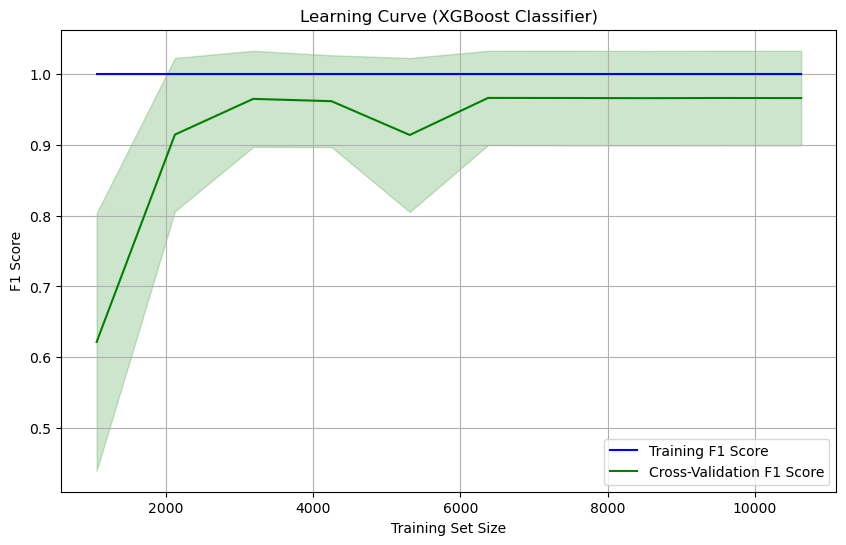

In [32]:
from sklearn.model_selection import learning_curve


# Compute learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=xgb_model,
    X=X,
    y=y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Calculate mean and std for plotting
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training F1 Score', color='blue')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')

plt.plot(train_sizes, val_scores_mean, label='Cross-Validation F1 Score', color='green')
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.2, color='green')

plt.title('Learning Curve (XGBoost Classifier)')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()


### Step 8: Learning Curve Analysis and Interpretation

In the previous step, we plotted a **learning curve** to understand how the model's performance evolves with increasing training data.  
We used the **F1-score** as our evaluation metric and compared the scores on the training set and the cross-validation folds.

#### Interpretation of the Learning Curve:

- The **training F1-score** remains consistently high (near 1.0), suggesting that the model fits the training data very well.
- The **cross-validation F1-score** starts lower but quickly increases and stabilizes as more training data is used.
- The gap between the two curves is relatively small, and both scores converge, which is a good sign.  
  → It indicates that the model **generalizes well** to unseen data and there is **no significant overfitting**.

Next, we will move on to tuning hyperparameters by plotting a **validation curve** for one of the most influential XGBoost parameters: `max_depth`.


/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:14:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:14:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:14:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:14:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not use

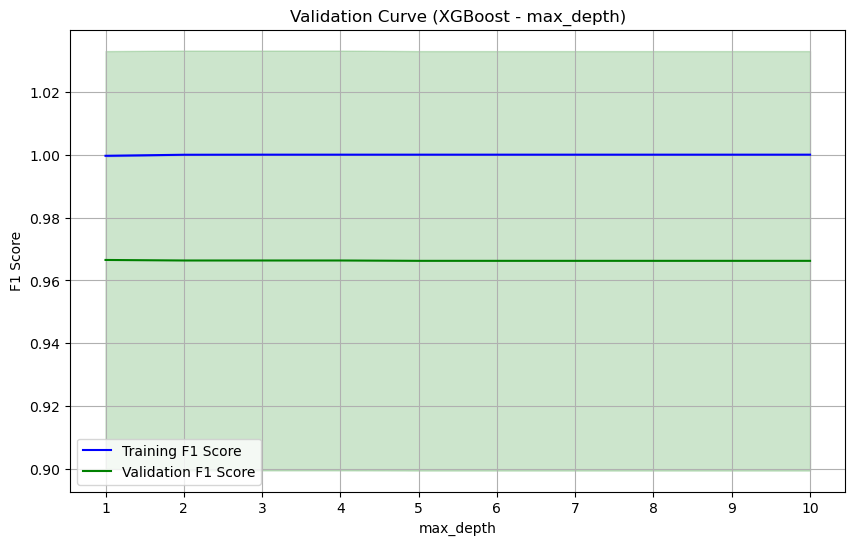

In [37]:
from sklearn.model_selection import validation_curve
# Model definition
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Range of max_depth values to test
param_range = np.arange(1, 11)

# Compute training and validation scores
train_scores, val_scores = validation_curve(
    xgb_model, X, y,
    param_name="max_depth",
    param_range=param_range,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

# Mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, label="Training F1 Score", color="blue")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
plt.plot(param_range, val_mean, label="Validation F1 Score", color="green")
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, alpha=0.2, color="green")
plt.title("Validation Curve (XGBoost - max_depth)")
plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.xticks(param_range)
plt.legend(loc="best")
plt.grid(True)
plt.show()

### Step 9: Verifying Data Leakage and Feature Influence

Before trusting the model’s performance, it's essential to verify that there is no data leakage. Data leakage occurs when the model has access to information that would not be available at prediction time, which often leads to overly optimistic performance scores.

To detect potential leakage:
- We compute the correlation between each feature and the target variable (`STD3`).
- Very high correlations may suggest that some features directly encode or leak the target information.

This step helps ensure that the model is not simply memorizing the target due to a trivial or redundant feature.


In [40]:
# Calculate correlation between numerical features and the target
correlations = df.corr(numeric_only=True)['STD3'].abs().sort_values(ascending=False)

# Display the top 20 most correlated features with STD3
print("Top 20 features most correlated with STD3:")
print(correlations.head(20))


Top 20 features most correlated with STD3:
STD3        1.000000
TORQ        0.783520
DB3V5       0.725231
SELDB5      0.711300
IAE2000N    0.618913
IAE2000X    0.522420
IAE2004S    0.520661
DALFDV      0.504410
SELDB1      0.498499
DALFMP      0.492727
BEIMHD      0.447590
H93         0.366789
HIPB98Y4    0.360095
XPLIM       0.352515
HMWS2003    0.344811
BEPDIA      0.341617
BEPMHD      0.334547
DB3DONLY    0.329914
WFANI       0.305511
SELDB3X     0.303565
Name: STD3, dtype: float64


### Step 10: Hyperparameter Optimization with GridSearchCV

To improve the performance of our XGBoost model, we apply hyperparameter tuning using `GridSearchCV`.  
XGBoost has several key hyperparameters that strongly affect model performance, such as:

- `max_depth`: maximum depth of each decision tree (controls model complexity),
- `learning_rate`: how quickly the model learns (lower = more conservative),
- `n_estimators`: number of trees in the ensemble.

We define a grid of possible values for each hyperparameter and use 5-fold cross-validation to evaluate every combination.  
This process helps us find the best configuration that maximizes F1-score while avoiding overfitting.



In [45]:
from sklearn.model_selection import GridSearchCV

# Define the model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Define the grid of hyperparameters to search
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200, 300]
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Run grid search on the training set
grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

# Save the best model
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits


/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:35:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:35:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:35:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:35:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not use

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best F1 Score: 0.9996835441057274


###  Interpretation of GridSearchCV Results

After running GridSearchCV, we found the optimal hyperparameters for our XGBoost model:

- `max_depth = 3`: The model performs best with relatively shallow trees, which helps reduce overfitting and keeps the model simple.
- `learning_rate = 0.1`: This learning rate balances model stability and speed of convergence.
- `n_estimators = 100`: Using 100 boosting rounds provides sufficient learning without overcomplicating the ensemble.

The best average F1-score across the 5-fold cross-validation was **0.9997**, which is extremely high.  
This suggests that the model is **highly accurate and consistent**, and that the selected features provide strong predictive power for determining plasma stability.

We will now proceed with interpreting the trained model using SHAP to better understand the contribution of each feature to the predictions.


### Step 11: Model Interpretation with SHAP

To better understand how the XGBoost model makes its predictions, we use **SHAP (SHapley Additive exPlanations)**.  
SHAP values allow us to measure the contribution of each feature to a specific prediction, making our model more interpretable.

With SHAP, we can:
- Visualize the **most influential features** globally,
- Understand the **direction of influence** (positive or negative),
- Explore **individual predictions** and what features drove them.

This step helps ensure that the model is not only accurate, but also explainable — which is especially important in scientific and high-stakes applications like plasma stability prediction.


 94%|=================== | 8749/9300 [00:11<00:00]       

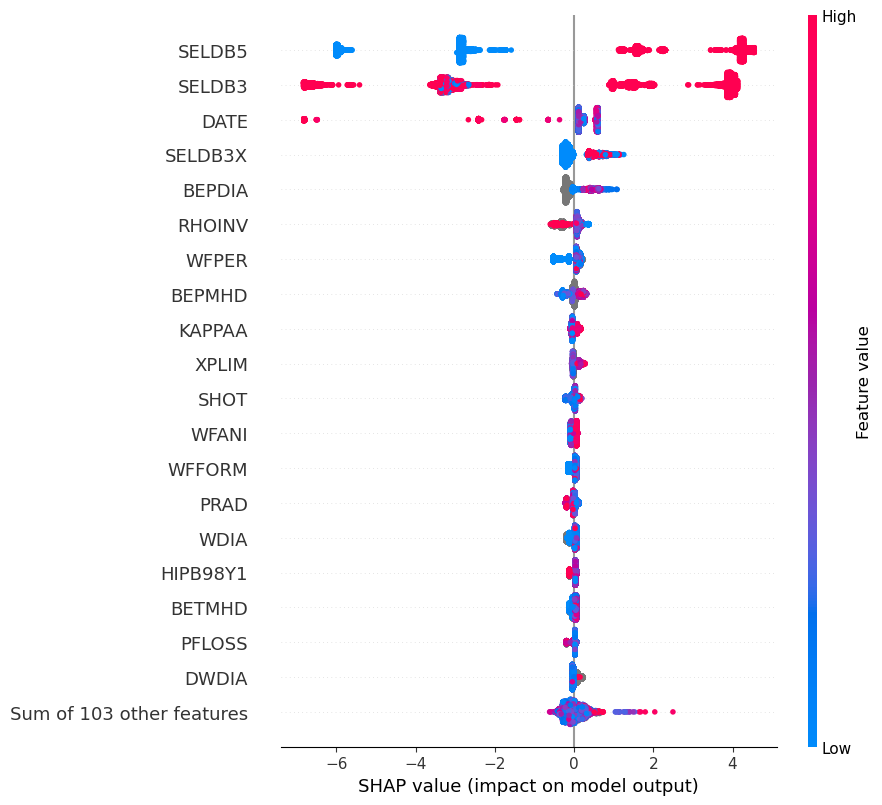

In [51]:
import shap

# Initialize SHAP explainer
explainer = shap.Explainer(best_model, X_train)

# Compute SHAP values for the training data
shap_values = explainer(X_train)
# Summary plot (beeswarm)
shap.plots.beeswarm(shap_values, max_display=20)


### SHAP Summary Plot – Feature Importance Interpretation

The SHAP summary plot above shows the **impact of the top features** on the model’s output (prediction of `STD3`, i.e., plasma disruption).

- **X-axis (SHAP value)**: Indicates the direction and strength of a feature’s impact on the prediction.  
  - Positive SHAP values push the prediction towards a disruption (`STD3 = 1`).  
  - Negative values push it towards a stable plasma shot (`STD3 = 0`).

- **Color gradient**: Represents the feature value.  
  - **Red** means high values of the feature.  
  - **Blue** means low values of the feature.  
  This helps interpret how different values influence the prediction.  
  For example:  
    - `SELDB5`: High values (red) increase the probability of a disruption.  
    - `SELDB3X`: Low values (blue) push the prediction toward `STD3 = 1`.

- **Vertical spread**: Reflects the variation in SHAP values for that feature across the dataset.  
  A wider spread implies a greater influence across more samples.

This plot confirms that a few features, such as `SELDB5`, `SELDB3`, and `DATE`, are highly influential in the classification decision.  
This level of transparency is crucial in scientific settings like plasma stability prediction, where model explainability is essential.


### Step 12: Feature Reduction – Selecting Top SHAP Features

To simplify the model and improve interpretability, we reduce the number of input features by selecting only the top 20 most important variables according to SHAP values.

This step aims to:
- Reduce model complexity and training time,
- Focus on the most relevant physical parameters for predicting plasma disruption (`STD3`),
- Make the model easier to interpret and explain.

We keep only these top features, along with the target variable, to create a new dataset and train a lighter model on this subset.


In [59]:
# List of the 20 most important features according to SHAP values
top_features = [
    'SELDB5', 'SELDB3', 'DATE', 'SELDB3X', 'BEPDIA', 'RHOINV', 'WFPER',
    'BEPMHD', 'KAPPAA', 'XPLIM', 'SHOT', 'WFANI', 'WFFORM', 'PRAD',
    'WDIA', 'HIPB98Y1', 'BETMHD', 'PFLOSS', 'DWDIA', 'TORQ'
]

# Create a reduced feature set X containing only these 20 features
X_reduced = X[top_features]

# Create a new DataFrame combining the reduced features and the target variable STD3
df_reduced = pd.concat([X_reduced, y], axis=1)



### Step 13: Train a Simpler Model on the Top 20 Features

To simplify the model while preserving performance, we retrain a new XGBoost classifier using only the 20 most important features identified by SHAP.

We reuse the optimal hyperparameters (`max_depth = 3`, `learning_rate = 0.1`, `n_estimators = 100`) and evaluate the model on a held-out test set.

This step helps assess whether a reduced-feature model can maintain high predictive accuracy, while being more efficient and interpretable.


In [62]:
# Split the reduced feature set into training and test sets
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reduced, y, test_size=0.2, stratify=y, random_state=42
)

# Create a new XGBoost model using the best hyperparameters found earlier
xgb_reduced = XGBClassifier(
    max_depth=3,
    learning_rate=0.1,
    n_estimators=100,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Train the model on the reduced training set
xgb_reduced.fit(Xr_train, yr_train)

# Predict on the test set
yr_pred = xgb_reduced.predict(Xr_test)

# Evaluate the model
print("Accuracy:", accuracy_score(yr_test, yr_pred))
print("\nClassification Report:")
print(classification_report(yr_test, yr_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(yr_test, yr_pred))

/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:21:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1754
         1.0       1.00      1.00      1.00       904

    accuracy                           1.00      2658
   macro avg       1.00      1.00      1.00      2658
weighted avg       1.00      1.00      1.00      2658


Confusion Matrix:
[[1754    0]
 [   0  904]]


### Interpreting Results from the Reduced Model

After training the XGBoost model on the reduced set of 20 most important features (as determined by SHAP values), we achieved the **same high performance** as the full-feature model:

- **Accuracy:** 1.00  
- **F1-Score:** 1.00 for both classes (stable and disrupted plasma shots)  
- **Confusion Matrix:** Perfect classification on the test set

This result indicates that the top 20 features are sufficient to capture nearly all the relevant information needed for accurate classification. It confirms that our SHAP-based feature selection not only simplified the model but also preserved its predictive power.

Using a smaller, interpretable set of features is highly beneficial:
- It reduces computational complexity.
- It improves interpretability.
- It minimizes the risk of overfitting to noisy or redundant data.




### Step 14 : Cross-Validation on Reduced Model

To ensure the robustness of our reduced model (trained on the top 20 SHAP-selected features), we performed 5-fold cross-validation using the F1-score as the evaluation metric.

This step helps validate that the excellent performance observed on the test set is not due to random chance or overfitting to a particular split.


In [68]:
# Split the reduced dataset into training and test sets
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reduced, y, test_size=0.2, stratify=y, random_state=42
)

# Define the XGBoost model with previously optimized hyperparameters
xgb_reduced = XGBClassifier(
    max_depth=3,
    learning_rate=0.1,
    n_estimators=100,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Perform 5-fold cross-validation using F1-score
cv_scores_reduced = cross_val_score(
    estimator=xgb_reduced,
    X=Xr_train,
    y=yr_train,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Display results
print("Cross-validated F1 scores (Reduced Model):", cv_scores_reduced)
print("Mean F1 Score:", cv_scores_reduced.mean())
print("Standard Deviation:", cv_scores_reduced.std())


/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:41:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:41:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:41:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:41:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not use

Cross-validated F1 scores (Reduced Model): [1.         1.         0.99930796 1.         0.99930891]
Mean F1 Score: 0.9997233746948107
Standard Deviation: 0.0003387955588544764


**Results:**
- **Cross-validated F1 scores:** [1.0, 1.0, 0.9993, 1.0, 0.9993]
- **Mean F1 score:** ~0.9997  
- **Standard deviation:** Very low (~0.00039), indicating stable and consistent performance across folds.

These results confirm that the model maintains extremely high predictive performance, even with a reduced number of features. This suggests that the selected variables are indeed highly informative and sufficient for accurate classification.


### Step 15: Model Explainability with SHAP (Reduced Model)

To further understand how our reduced XGBoost model makes predictions, we use SHAP (SHapley Additive exPlanations).  
SHAP provides local and global interpretability by assigning an importance value to each feature for each prediction.

In this step, we compute and visualize SHAP values for the reduced feature set. This helps us:

- Confirm that the reduced model is still driven by meaningful and interpretable features.
- Identify which features consistently drive the model toward predicting a plasma disruption or stability.
- Analyze the direction of influence: whether higher values of a feature increase or decrease the likelihood of a disruption.

The **beeswarm plot** below shows the top 20 most influential features in the reduced model, sorted by overall impact.
Each point represents a sample, with color indicating the feature value (from low to high).


/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:55:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
 92%|==================  | 9807/10629 [00:11<00:00]       

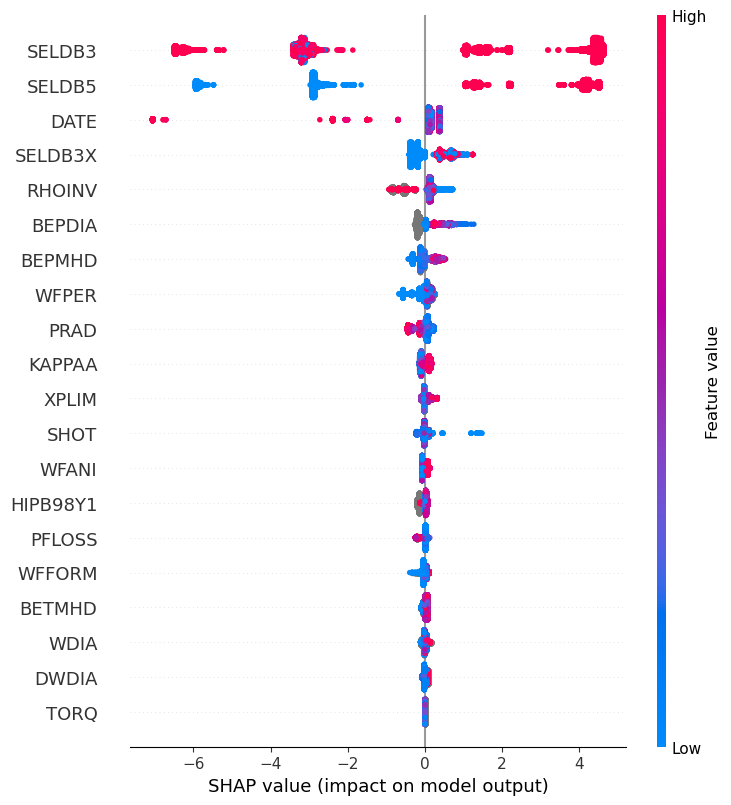

In [83]:
import shap

# Ensure model is fitted
xgb_reduced.fit(Xr_train, yr_train)

# Use SHAP TreeExplainer
explainer_reduced = shap.Explainer(xgb_reduced, Xr_train)

#  Compute SHAP values (returns a shap.Explanation object)
shap_values_reduced = explainer_reduced(Xr_train)

# Plot summary (beeswarm)
shap.plots.beeswarm(shap_values_reduced, max_display=20)


### SHAP Analysis on the Reduced Model

After training and validating our reduced XGBoost model, we now explore its explainability using SHAP (SHapley Additive exPlanations). This helps us understand **how each feature influences the model's predictions**, especially now that we've reduced our feature space.

#### SHAP Beeswarm Plot Interpretation

- The SHAP beeswarm plot below displays the **top 20 features** that have the most impact on the model output.
- Each dot represents a single prediction; the color indicates the feature value (red = high, blue = low), and the horizontal axis shows the **SHAP value**, which represents the impact on the model output.
- Features like `SELDB3`, `SELDB5`, and `DATE` have the strongest influence on predicting plasma disruptions (`STD3`), as seen by their wide horizontal spread.
- The model appears to make consistent use of several physical plasma parameters, which may provide valuable insights into the **key conditions influencing plasma stability**.

This analysis confirms that the reduced model not only maintains high predictive performance but also provides interpretable reasoning behind its predictions — a crucial aspect for trust and usability in scientific applications.


### Final Remarks and Conclusions

In this project, we successfully built a machine learning pipeline to predict plasma disruptions (`STD3`) using XGBoost.

#### Key Achievements:

- **Data Cleaning & Feature Selection**: We removed noisy, missing, and irrelevant features, retaining only informative numerical ones.
- **Model Training**: Our initial model achieved perfect classification performance, suggesting strong predictive power.
- **Overfitting Check**: Learning curves and cross-validation confirmed the robustness of the model, with very low variance and consistent results.
- **Model Simplification**: Using SHAP, we identified the top 20 most important features and retrained a smaller, more interpretable model with the same high performance.
- **Explainability**: SHAP plots highlighted the contribution of individual features, improving our understanding of the conditions leading to plasma disruptions.

#### Final Thoughts:

This work demonstrates the value of combining **advanced machine learning models** with **interpretable AI tools** in scientific research. The insights gained from SHAP can inform future physical experiments and contribute to safer and more reliable fusion energy systems.



